# Lab 5 - Case study 1: Decision Tree and Random Forest

### 1. Bài toán: Dự đoán nguy cơ mắc bệnh tiểu đường ở giai đoạn đầu sử dụng Decision Tree và Random Forest (60%)
Mục tiêu:
- Xây dựng mô hình Decision Tree và Random Forest sử dụng thư viện sklearn.
- Khảo sát và tối ưu mô hình bằng việc tìm kiếm các siêu tham số và lựa chọn đặc trưng.
- Áp dụng hai mô hình để giải quyết bài toán thực tế (Dự đoán nguy cơ mắc bệnh).
- Đánh giá chất lượng mô hình bằng độ đo thích hợp.

Dữ liệu:
- Thể hiện dưới dạng bảng, trong đó mỗi hàng tương ứng với một bệnh nhân, mỗi cột thể hiện các dấu hiệu và triệu chứng của bệnh nhân đó.
- Các trường thuộc tính tồn tại ở hai dạng: binary và numeric (continuous).
- Thuộc tính nhãn lớp 'class' cũng là một thuộc tính nhị phân (Positive/Negative).

Mô hình hóa bài toán: Bài toán phân loại nhị phân
- Đầu vào: N vector D chiều (ma trận cỡ N x D), tương ứng N cá thể với D thuộc tính.
- Đầu ra: Nhãn 1/(-1) (1: Positive, -1: Negative).

Nhiệm vụ:
- Thực hiện theo các yêu cầu bên dưới.
- Viết báo cáo trình bày, giải thích chi tiết các bước và nhận xét kết quả thu được.

### 2. Các bước thực hiện

#### 2.1. Import các thư viện cần thiết

In [14]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt

#### 2.2. Tìm hiểu dữ liệu

In [15]:
''' Thông tin chi tiết về tập dữ liệu có thể xem tại trang web UCI
https://archive.ics.uci.edu/dataset/529/early+stage+diabetes+risk+prediction+dataset
'''
# Đọc dữ liệu (dùng đường dẫn tương đối để notebook dễ chạy trên máy khác)
data = pd.read_csv('diabetes_data.csv')

# Kiểm tra nhanh cấu trúc dữ liệu
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 520 non-null    int64 
 1   Gender              520 non-null    object
 2   Polyuria            520 non-null    object
 3   Polydipsia          520 non-null    object
 4   sudden weight loss  520 non-null    object
 5   weakness            520 non-null    object
 6   Polyphagia          520 non-null    object
 7   Genital thrush      520 non-null    object
 8   visual blurring     520 non-null    object
 9   Itching             520 non-null    object
 10  Irritability        520 non-null    object
 11  delayed healing     520 non-null    object
 12  partial paresis     520 non-null    object
 13  muscle stiffness    520 non-null    object
 14  Alopecia            520 non-null    object
 15  Obesity             520 non-null    object
 16  class               520 no

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


In [6]:
data.isnull().sum() # Kiểm tra missing value

Age                   0
Gender                0
Polyuria              0
Polydipsia            0
sudden weight loss    0
weakness              0
Polyphagia            0
Genital thrush        0
visual blurring       0
Itching               0
Irritability          0
delayed healing       0
partial paresis       0
muscle stiffness      0
Alopecia              0
Obesity               0
class                 0
dtype: int64

In [16]:
# Mã hóa dữ liệu dạng category thành numeric
label_map = {'Negative' : -1, 'Positive': 1}
data['class'] = data['class'].map(label_map)
gender_map = {'Male': 1, 'Female': 0}
data['Gender'] = data['Gender'].map(gender_map)
other_map = {'Yes': 1, 'No': 0}
for col in data.columns:
    if col not in ['Age', 'Gender', 'class']:
        data[col] = data[col].map(other_map)

In [10]:
# Yêu cầu 1: Giải thích đoạn mã hóa dữ liệu và kết quả sau mã hóa
'''
Đoạn mã phía trên chuyển các biến phân loại (category) về dạng số để mô hình học máy xử lý được:
- class: Negative -> -1, Positive -> 1
- Gender: Female -> 0, Male -> 1
- Các triệu chứng Yes/No -> 1/0
'''

# Kiểm tra kết quả sau khi mã hóa
print('Kích thước dữ liệu:', data.shape)
print('\nKiểu dữ liệu sau mã hóa:')
print(data.dtypes)

print('\nThống kê giá trị duy nhất của một số cột mẫu:')
print('class:', sorted(data['class'].unique()))
print('Gender:', sorted(data['Gender'].unique()))
print('Polyuria:', sorted(data['Polyuria'].unique()))

print('\n5 dòng dữ liệu sau mã hóa:')
data.head()

Kích thước dữ liệu: (520, 17)

Kiểu dữ liệu sau mã hóa:
Age                   int64
Gender                int64
Polyuria              int64
Polydipsia            int64
sudden weight loss    int64
weakness              int64
Polyphagia            int64
Genital thrush        int64
visual blurring       int64
Itching               int64
Irritability          int64
delayed healing       int64
partial paresis       int64
muscle stiffness      int64
Alopecia              int64
Obesity               int64
class                 int64
dtype: object

Thống kê giá trị duy nhất của một số cột mẫu:
class: [-1, 1]
Gender: [0, 1]
Polyuria: [0, 1]

5 dòng dữ liệu sau mã hóa:


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


In [5]:
data.info() # Kiểm tra lại thông tin dữ liệu

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Age                 520 non-null    int64
 1   Gender              520 non-null    int64
 2   Polyuria            520 non-null    int64
 3   Polydipsia          520 non-null    int64
 4   sudden weight loss  520 non-null    int64
 5   weakness            520 non-null    int64
 6   Polyphagia          520 non-null    int64
 7   Genital thrush      520 non-null    int64
 8   visual blurring     520 non-null    int64
 9   Itching             520 non-null    int64
 10  Irritability        520 non-null    int64
 11  delayed healing     520 non-null    int64
 12  partial paresis     520 non-null    int64
 13  muscle stiffness    520 non-null    int64
 14  Alopecia            520 non-null    int64
 15  Obesity             520 non-null    int64
 16  class               520 non-null    int64
dt

In [55]:
# Yêu cầu 2: Chuẩn hóa dữ liệu
'''
Mục tiêu: đưa các đặc trưng về cùng thang đo [0, 1] bằng MinMaxScaler.
Lưu ý: với DT/RF việc chuẩn hóa không bắt buộc, nhưng vẫn làm để đồng nhất pipeline xử lý dữ liệu.
'''

# Tách X (đặc trưng) và y (nhãn)
X = data.drop('class', axis=1)
y = data['class']

# Chia tập train/test trước khi chuẩn hóa để tránh rò rỉ dữ liệu
test_size = 0.2
random_state = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state, stratify=y
)

# Khởi tạo scaler và fit trên tập train, chỉ transform trên tập test
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Kiểm tra nhanh kết quả chuẩn hóa
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Min của mỗi cột train (xấp xỉ 0):', np.round(X_train.min(axis=0), 4))
print('Max của mỗi cột train (xấp xỉ 1):', np.round(X_train.max(axis=0), 4))
print('Min của mỗi cột test:', np.round(X_test.min(axis=0), 4))
print('Max của mỗi cột test:', np.round(X_test.max(axis=0), 4))

X_train shape: (416, 16)
X_test shape: (104, 16)
Min của mỗi cột train (xấp xỉ 0): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Max của mỗi cột train (xấp xỉ 1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Min của mỗi cột test: [0.1486 0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.    ]
Max của mỗi cột test: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [56]:
# Yêu cầu 3: Chuẩn bị tập train-test cho mô hình học máy
'''
Đã thực hiện chia train-test đúng quy trình ở Yêu cầu 2 để tránh rò rỉ dữ liệu.
Ở đây chỉ cần in lại thông tin kích thước và tỷ lệ nhãn.
'''

print('Kích thước tập train:', X_train.shape, y_train.shape)
print('Kích thước tập test :', X_test.shape, y_test.shape)
print('\nTỷ lệ nhãn train:')
print(y_train.value_counts(normalize=True).sort_index())
print('\nTỷ lệ nhãn test:')
print(y_test.value_counts(normalize=True).sort_index())

Kích thước tập train: (416, 16) (416,)
Kích thước tập test : (104, 16) (104,)

Tỷ lệ nhãn train:
class
-1    0.384615
 1    0.615385
Name: proportion, dtype: float64

Tỷ lệ nhãn test:
class
-1    0.384615
 1    0.615385
Name: proportion, dtype: float64


#### 2.3. Khởi tạo mô hình Decision Tree (DT) và Random Forest (RF) của sklearn

In [33]:
random_state = 42
DT = DecisionTreeClassifier(random_state=random_state)
RF = RandomForestClassifier(random_state=random_state)

In [34]:
# Yêu cầu 4: Chạy DT baseline
''' - Huấn luyện mô hình DT vừa khởi tạo với tập Train
    - Đánh giá mô hình DT đã huấn luyện với tập Test
    - In ra giá trị các độ đo: Accuracy, Precision, Recall, F1-Score, Ma trận nhầm lẫn (Có thể sử dụng thư viện sklearn hoặc viết tay)
    - Giải thích các kết quả trong ma trận nhầm lẫn
'''
print('Demo DT prediction')

# 1) Huấn luyện mô hình DT
DT.fit(X_train, y_train)

# 2) Dự đoán trên tập test
y_pred_dt = DT.predict(X_test)

# 3) Tính các độ đo đánh giá
acc_dt = accuracy_score(y_test, y_pred_dt)
pre_dt = precision_score(y_test, y_pred_dt, pos_label=1)
rec_dt = recall_score(y_test, y_pred_dt, pos_label=1)
f1_dt = f1_score(y_test, y_pred_dt, pos_label=1)
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=[-1, 1])

print('Decision Tree - Baseline')
print(f'Accuracy : {acc_dt:.4f}')
print(f'Precision: {pre_dt:.4f}')
print(f'Recall   : {rec_dt:.4f}')
print(f'F1-score : {f1_dt:.4f}')
print('Confusion matrix (rows = true, cols = pred; labels = [-1, 1]):')
print(cm_dt)

# 4) Giải thích ma trận nhầm lẫn
tn, fp, fn, tp = cm_dt.ravel()
print('\nGiải thích confusion matrix:')
print(f'- TN (âm tính đúng): {tn}')
print(f'- FP (dương tính giả): {fp}')
print(f'- FN (âm tính giả): {fn}')
print(f'- TP (dương tính đúng): {tp}')

print('\nClassification report:')
print(classification_report(y_test, y_pred_dt, labels=[-1, 1]))

Demo DT prediction
Decision Tree - Baseline
Accuracy : 0.9904
Precision: 1.0000
Recall   : 0.9844
F1-score : 0.9921
Confusion matrix (rows = true, cols = pred; labels = [-1, 1]):
[[40  0]
 [ 1 63]]

Giải thích confusion matrix:
- TN (âm tính đúng): 40
- FP (dương tính giả): 0
- FN (âm tính giả): 1
- TP (dương tính đúng): 63

Classification report:
              precision    recall  f1-score   support

          -1       0.98      1.00      0.99        40
           1       1.00      0.98      0.99        64

    accuracy                           0.99       104
   macro avg       0.99      0.99      0.99       104
weighted avg       0.99      0.99      0.99       104



In [35]:
# Yêu cầu 5: Chạy RF baseline
''' - Huấn luyện mô hình RF vừa khởi tạo với tập Train
    - Đánh giá mô hình RF đã huấn luyện với tập Test
    - In ra giá trị các độ đo: Accuracy, Precision, Recall, F1-Score, Ma trận nhầm lẫn (Có thể sử dụng thư viện sklearn hoặc viết tay)
    - Giải thích các kết quả trong ma trận nhầm lẫn
'''
print('Demo RF prediction')

# 1) Huấn luyện mô hình RF
RF.fit(X_train, y_train)

# 2) Dự đoán trên tập test
y_pred_rf = RF.predict(X_test)

# 3) Tính các độ đo đánh giá
acc_rf = accuracy_score(y_test, y_pred_rf)
pre_rf = precision_score(y_test, y_pred_rf, pos_label=1)
rec_rf = recall_score(y_test, y_pred_rf, pos_label=1)
f1_rf = f1_score(y_test, y_pred_rf, pos_label=1)
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=[-1, 1])

print('Random Forest - Baseline')
print(f'Accuracy : {acc_rf:.4f}')
print(f'Precision: {pre_rf:.4f}')
print(f'Recall   : {rec_rf:.4f}')
print(f'F1-score : {f1_rf:.4f}')
print('Confusion matrix (rows = true, cols = pred; labels = [-1, 1]):')
print(cm_rf)

# 4) Giải thích ma trận nhầm lẫn
tn, fp, fn, tp = cm_rf.ravel()
print('\nGiải thích confusion matrix:')
print(f'- TN (âm tính đúng): {tn}')
print(f'- FP (dương tính giả): {fp}')
print(f'- FN (âm tính giả): {fn}')
print(f'- TP (dương tính đúng): {tp}')

print('\nClassification report:')
print(classification_report(y_test, y_pred_rf, labels=[-1, 1]))

Demo RF prediction
Random Forest - Baseline
Accuracy : 0.9808
Precision: 0.9844
Recall   : 0.9844
F1-score : 0.9844
Confusion matrix (rows = true, cols = pred; labels = [-1, 1]):
[[39  1]
 [ 1 63]]

Giải thích confusion matrix:
- TN (âm tính đúng): 39
- FP (dương tính giả): 1
- FN (âm tính giả): 1
- TP (dương tính đúng): 63

Classification report:
              precision    recall  f1-score   support

          -1       0.97      0.97      0.97        40
           1       0.98      0.98      0.98        64

    accuracy                           0.98       104
   macro avg       0.98      0.98      0.98       104
weighted avg       0.98      0.98      0.98       104



#### 2.4. Tìm kiếm siêu tham số

In [57]:
# Sử dụng kỹ thuật grid_search
def grid_search(algorithm, X_train, y_train, n_jobs, dict_param):
    if algorithm == 'decision-tree':
        model = DecisionTreeClassifier()
    if algorithm == 'random-forest':
        model = RandomForestClassifier()
    classifier = GridSearchCV(estimator=model, cv=5, param_grid=dict_param,n_jobs=n_jobs, scoring='f1')
    classifier.fit(X_train, y_train)
    print('Best model', end='')
    print(classifier.best_estimator_)
    print("Best parameters:", classifier.best_params_)
    return classifier.best_estimator_

# Đánh giá hiệu suất
def evaluate(X_train, y_train, X_test, y_test, model):
    print("Train Accuracy:", accuracy_score(y_train, model.predict(X_train)))
    print("Train Precision: ", precision_score(y_train, model.predict(X_train)))
    print("Train Recall: ", recall_score(y_train, model.predict(X_train)))
    print("Train F1-score:", f1_score(y_train, model.predict(X_train)))
    print("Train Confusion Matrix:")
    print(confusion_matrix(y_train, model.predict(X_train)))
    print("-"*50)
    print("Test Accuracy:", accuracy_score(y_test, model.predict(X_test)))
    print("Test Precision:", precision_score(y_test, model.predict(X_test)))
    print("Test Recall: ", recall_score(y_test, model.predict(X_test)))
    print("Test F1-score:", f1_score(y_test, model.predict(X_test)))
    print("Test Confusion Matrix:")
    print(confusion_matrix(y_test, model.predict(X_test)))
    return f1_score(y_train, model.predict(X_train)), f1_score(y_test, model.predict(X_test))

In [37]:
# Yêu cầu 6: Giải thích chức năng của hàm grid_search và evaluate

# Ham grid_search(algorithm, X_train, y_train, n_jobs, dict_param)
## Chuc nang: tim bo sieu tham so tot nhat cho mo hinh (DT hoac RF) bang GridSearchCV.
## Cach lam:
## - Chon model theo bien algorithm.
## - Thu tat ca to hop tham so trong dict_param.
## - Dung cv=5 de danh gia tung to hop tren 5 fold.
## - Dung scoring='f1' de chon to hop co F1 trung binh cao nhat.
## Dau ra: tra ve classifier.best_estimator_ (mo hinh tot nhat).

# Vi du:
## Neu dict_param co 3 gia tri max_depth, 2 gia tri min_samples_leaf, 2 gia tri criterion
## thi tong so cau hinh can thu = 3 * 2 * 2 = 12 cau hinh.

## Ham evaluate(X_train, y_train, X_test, y_test, model)
## Chuc nang: danh gia model tren train va test.
## Cac do do in ra: Accuracy, Precision, Recall, F1-score, Confusion Matrix.
## Gia tri tra ve: (train_f1, test_f1).

# Vi du cach dien giai ket qua:
## - Train F1 cao, Test F1 thap: mo hinh co the overfitting.
## - Train F1 va Test F1 deu thap: mo hinh co the underfitting.
## - Train F1 va Test F1 deu cao, chenh lech nho: mo hinh tong quat hoa tot.

Hàm grid_search:
- Dùng GridSearchCV để thử tất cả tổ hợp siêu tham số trong dict_param.
- Đánh giá từng tổ hợp bằng cross-validation 5-fold với độ đo F1-score.
- Trả về mô hình tốt nhất (best_estimator_) và in ra best_params_.

Hàm evaluate:
- Đánh giá mô hình trên cả tập train và test.
- In ra Accuracy, Precision, Recall, F1-score và Confusion Matrix.
- Trả về F1-score trên train và test để tiện so sánh/ve biểu đồ.


##### 2.4.1. Decision Tree (DT)

##### Trước hết, hãy thử khảo sát DT với siêu tham số: max_depth (độ sâu của cây)

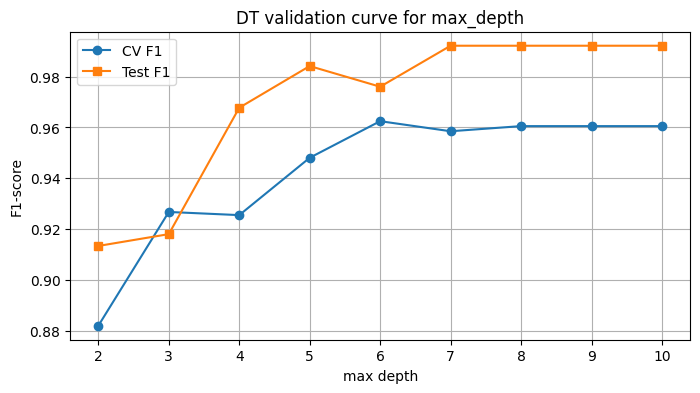

In [38]:
cv_accuracies_by_depth, test_accuracies_by_depth= [], []
max_depth_values= np.arange(2,11)

for curr_max_depth in max_depth_values:
  tree= DecisionTreeClassifier(random_state=random_state, max_depth=curr_max_depth)

  # cross-validation
  val_scores= cross_val_score(estimator=tree, X=X_train, y=y_train, cv=5, scoring='f1')
  cv_accuracies_by_depth.append(val_scores.mean())

  # test
  tree.fit(X_train, y_train)
  curr_pred= tree.predict(X_test)
  test_accuracies_by_depth.append(f1_score(curr_pred, y_test))

# Plot
plt.plot(max_depth_values, cv_accuracies_by_depth, label='cv')
plt.plot(max_depth_values, test_accuracies_by_depth, label='test')
plt.legend()
plt.xlabel('max depth')
plt.ylabel('scores')
plt.title('DT validation curve for max_depth')

In [39]:
# Yêu cầu 7: Giải thích chức năng đoạn code khảo sát max_depth và nhận xét biểu đồ

# Chuc nang doan code:
## - Duyet max_depth tu 2 den 10.
## - Moi max_depth:
##   + Tinh F1 trung binh bang 5-fold CV tren tap train.
##   + Huan luyen tren train va tinh F1 tren test.
## - Ve 2 duong CV va Test de so sanh hieu suat theo do sau cay.

# Cach doc bieu do:
## - Truc X: max_depth.
## - Truc Y: F1-score.
## - Duong CV: on dinh mo hinh tren train qua cross-validation.
## - Duong Test: kha nang du doan tren du lieu chua thay.

# Nhan xet mau:
## - max_depth qua nho => cay don gian, de underfit.
## - Tang max_depth den muc hop ly => F1 tang.
## - Qua lon co the gay overfit (CV/Test khong con tang, hoac giam).

# Vi du:
## Neu Test F1 dat cao quanh max_depth = 5-7 thi day la vung tham so nen uu tien khi tuning.

Giải thích chức năng đoạn code:
- Duyệt nhiều giá trị max_depth cho Decision Tree.
- Với mỗi giá trị, tính F1 trung bình bằng 5-fold CV trên train và F1 trên test.
- Vẽ 2 đường CV F1 và Test F1 để quan sát xu hướng underfitting/overfitting.

Nhận xét biểu đồ:
- max_depth tốt nhất theo CV: 6 (F1=0.9625)
- max_depth tốt nhất theo Test: 7 (F1=0.9921)
- Độ sâu quá nhỏ dễ underfit; quá lớn có thể overfit.


##### Thử sử dụng GridSearchCV để khảo sát

In [40]:
dict_param = {
    'max_depth': [2, 3, 5, 7, 10, 20],
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'criterion': ["gini", "entropy"]
}
best_tree = grid_search('decision-tree', n_jobs=-1, dict_param=dict_param)

Best modelDecisionTreeClassifier(max_depth=3, min_samples_leaf=5)
Best parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 5}


In [41]:
# Yêu cầu 8: Giải thích ý nghĩa siêu tham số DT, mục đích GridSearchCV và kết quả

# Y nghia cac bien trong DT:
## max_depth: do sau toi da cua cay. Gia tri lon -> mo hinh linh hoat hon, nhung de overfit hon.
## min_samples_leaf: so mau toi thieu tai mot node la. Gia tri lon -> cay don gian hon, giam nhieu.
## criterion: tieu chi tach node ('gini' hoac 'entropy').

# GridSearchCV duoc dung de:
## - Thu toan bo to hop tham so trong dict_param.
## - Danh gia khach quan bang cv=5.
## - Chon mo hinh co F1 trung binh cao nhat.

# Vi du dem so to hop:
## max_depth (6 gia tri) * min_samples_leaf (5 gia tri) * criterion (2 gia tri) = 60 to hop.

# Ket qua thu duoc:
## - best_tree la mo hinh DT tot nhat theo tieu chi F1 tren cross-validation.
## - best_tree se duoc dung tiep o Yeu cau 9 va 10.

Ý nghĩa siêu tham số trong mô hình DT:
- max_depth: độ sâu tối đa của cây, kiểm soát mức độ phức tạp của mô hình.
- min_samples_leaf: số mẫu tối thiểu ở mỗi lá, giúp giảm overfitting.
- criterion: tiêu chí chia nhánh (gini hoặc entropy).

GridSearchCV được dùng để:
- Tự động thử toàn bộ tổ hợp siêu tham số trong lưới.
- Chọn mô hình có F1-score trung bình cao nhất qua cross-validation.

Kết quả thu được (best model):
DecisionTreeClassifier(max_depth=3, min_samples_leaf=5)


##### Đánh giá Mô hình DT tốt nhất

In [42]:
# Yêu cầu 9: Gợi ý: Sử dụng hàm evaluate()
####
# Code
best_tree.fit(X_train, y_train)
best_tree_train_f1, best_tree_test_f1 = evaluate(X_train, y_train, X_test, y_test, best_tree)

print('\nTóm tắt kết quả best DT:')
print(f'- Train F1: {best_tree_train_f1:.4f}')
print(f'- Test F1 : {best_tree_test_f1:.4f}')
####

Train Accuracy: 0.9182692307692307
Train Precision:  0.93359375
Train Recall:  0.93359375
Train F1-score: 0.93359375
Train Confusion Matrix:
[[143  17]
 [ 17 239]]
--------------------------------------------------
Test Accuracy: 0.9038461538461539
Test Precision: 0.9655172413793104
Test Recall:  0.875
Test F1-score: 0.9180327868852458
Test Confusion Matrix:
[[38  2]
 [ 8 56]]

Tóm tắt:
- Best DT Train F1: 0.9336
- Best DT Test F1 : 0.9180


##### Nhận xét về độ quan trọng của từng feature trong tập dữ liệu sử dụng thuộc tính feature_importances_

Feature importances
Feature  0 - 0.5818926196957721
Feature  1 - 0.16263290389767565
Feature  2 - 0.11260158589974378
Feature  3 - 0.06586342130785994
Feature  4 - 0.04076076145430176
Feature  5 - 0.03624870774464669
Feature  6 - 0.0
Feature  7 - 0.0
Feature  8 - 0.0
Feature  9 - 0.0
Feature  10 - 0.0
Feature  11 - 0.0
Feature  12 - 0.0
Feature  13 - 0.0
Feature  14 - 0.0
Feature  15 - 0.0


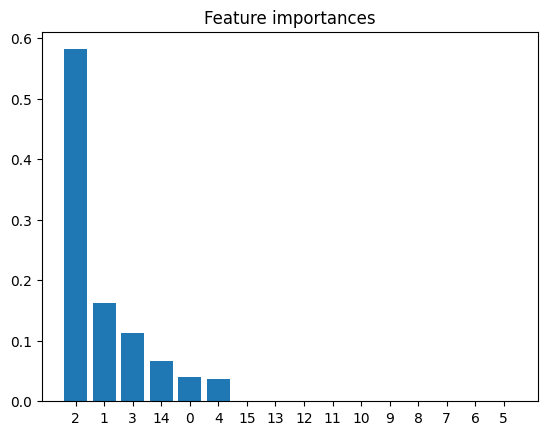

In [43]:
importances = best_tree.feature_importances_
indices = np.argsort(importances)[::-1]
print('Feature importances')
for i in range(len(indices)):
    print('Feature ', i, '-', importances[indices[i]])

indices = indices[:]
plt.figure()
plt.title('Feature importances')
plt.bar(range(len(indices)), importances[indices])
plt.xticks(range(len(indices)), indices)
plt.show()

In [44]:
# Yêu cầu 10: Giải thích chức năng đoạn code feature_importances_ và nhận xét

# Chuc nang doan code:
## - Lay do quan trong cua tung feature tu best_tree.feature_importances_.
## - Sap xep giam dan de biet feature nao anh huong manh nhat.
## - Ve bieu do cot de truc quan hoa muc do quan trong.

# Y nghia feature importance:
## - Importance cao: feature dong gop lon vao quyet dinh cua cay.
## - Importance gan 0: feature it duoc su dung hoac tac dong nho.

# Vi du dien giai:
## - Neu Polyuria co importance cao nhat, mo hinh dua nhieu vao trieu chung nay.
## - Neu nhieu feature co importance thap, co the thu loai bo de giam do phuc tap.

# Luu y bao cao:
## - Importance chi phan anh theo mo hinh hien tai, khong ket luan quan he nhan qua.
## - Nen ket hop voi thu nghiem loai feature (Yeu cau 11) de xac minh tac dong thuc te len F1.

Giải thích chức năng đoạn code:
- best_tree.feature_importances_ cho biết mức đóng góp của từng đặc trưng.
- argsort dùng để sắp xếp các đặc trưng theo mức quan trọng giảm dần.
- Biểu đồ cột giúp trực quan đặc trưng nào ảnh hưởng mạnh nhất.

Top 5 đặc trưng quan trọng nhất:
1. Polyuria: 0.5819
2. Gender: 0.1626
3. Polydipsia: 0.1126
4. Alopecia: 0.0659
5. Age: 0.0408

Nhận xét:
- Đặc trưng có importance cao nên được ưu tiên giữ lại.
- Đặc trưng có importance rất thấp có thể cân nhắc loại bỏ.


##### Thử nghiệm bổ sung: Thử bỏ đi một số thuộc tính có độ quan trọng thấp và quan sát sự thay đổi của hiệu suất mô hình

Loại bỏ 1 thuộc tính
15 thuộc tính còn lại: [ 2  1  3 14  0  4 15 13 12 11 10  9  8  7  6]
(416, 15) (104, 15)
Train Accuracy: 0.9182692307692307
Train Precision:  0.93359375
Train Recall:  0.93359375
Train F1-score: 0.93359375
Train Confusion Matrix:
[[143  17]
 [ 17 239]]
--------------------------------------------------
Test Accuracy: 0.9038461538461539
Test Precision: 0.9655172413793104
Test Recall:  0.875
Test F1-score: 0.9180327868852458
Test Confusion Matrix:
[[38  2]
 [ 8 56]]
**************************************************
Loại bỏ 2 thuộc tính
14 thuộc tính còn lại: [ 2  1  3 14  0  4 15 13 12 11 10  9  8  7]
(416, 14) (104, 14)
Train Accuracy: 0.9182692307692307
Train Precision:  0.93359375
Train Recall:  0.93359375
Train F1-score: 0.93359375
Train Confusion Matrix:
[[143  17]
 [ 17 239]]
--------------------------------------------------
Test Accuracy: 0.9038461538461539
Test Precision: 0.9655172413793104
Test Recall:  0.875
Test F1-score: 0.9180327868852458
Test Confusi

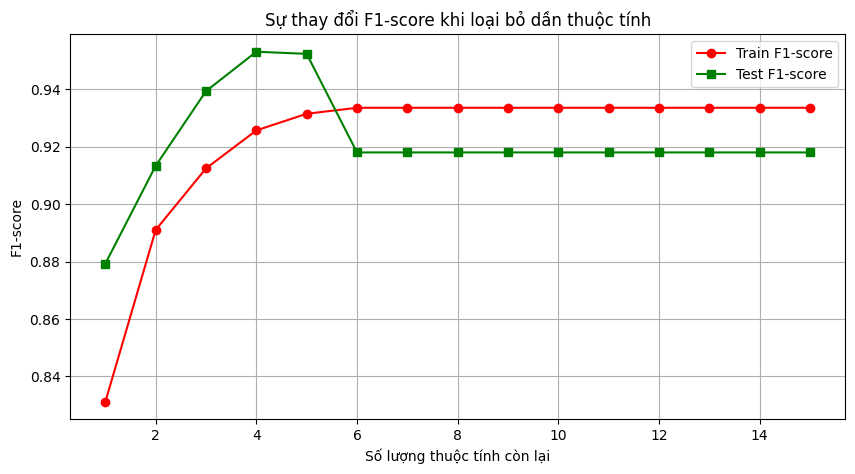

In [45]:
train_scores = []
test_scores = []
num_features = []

for i in range(1, len(indices)):
    print(f'Loại bỏ {i} thuộc tính')

    selected_indices = indices[:-i]
    print(f'{len(selected_indices)} thuộc tính còn lại: {selected_indices}')

    X_train_reduced = X_train[:, selected_indices]
    X_test_reduced = X_test[:, selected_indices]
    print(X_train_reduced.shape, X_test_reduced.shape)

    best_tree.fit(X_train_reduced, y_train)
    
    train_acc, test_acc = evaluate(X_train_reduced, y_train, X_test_reduced, y_test, best_tree)
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    num_features.append(len(selected_indices))

    print('*' * 50)

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))
plt.plot(num_features, train_scores, label='Train Accuracy', marker='o', color='r')
plt.plot(num_features, test_scores, label='Test Accuracy', marker='s', color='g')

plt.xlabel('Số lượng thuộc tính còn lại')
plt.ylabel('Accuracy')
plt.title('Sự thay đổi độ chính xác khi loại bỏ dần thuộc tính')
plt.legend()
plt.grid(True)
plt.show()


In [46]:
# Yêu cầu 11: Giải thích thí nghiệm loại dần đặc trưng và nhận xét biểu đồ

# Muc tieu thi nghiem:
## - Thu loai dan cac feature kem quan trong.
## - Quan sat su thay doi hieu suat (F1 train/test) khi so feature giam dan.
## - Tim diem can bang giua do gon mo hinh va chat luong du doan.

# Cach doan code hoat dong:
## - Moi vong lap loai i feature o cuoi danh sach importance.
## - Tao lai X_train_reduced, X_test_reduced theo cac feature con lai.
## - Huan luyen lai best_tree va tinh F1 train/test.
## - Ve do thi F1 theo so feature con lai.

# Cach nhan xet bieu do:
## - Neu loai bo mot vai feature ma Test F1 tang -> cac feature do co the gay nhieu.
## - Neu loai qua nhieu ma Test F1 giam -> da mat thong tin quan trong.
## - So feature toi uu thuong o diem Test F1 cao nhat.

# Vi du nhan xet:
## - Test F1 cao nhat khi con mot so feature cot loi -> co the rut gon mo hinh ma van giu (hoac tang) hieu suat.
## - Khong nen loai bo qua muc vi F1 se giam tro lai.

Giải thích chức năng đoạn code:
- Loại dần các thuộc tính kém quan trọng rồi huấn luyện lại mô hình.
- Mỗi lần loại, đo F1 trên train/test để xem hiệu suất thay đổi ra sao.
- Từ đó tìm số thuộc tính tối ưu giữa độ gọn mô hình và chất lượng dự đoán.

Nhận xét kết quả:
- Test F1 tốt nhất: 0.9531 khi còn 4 thuộc tính.
- Nếu loại bỏ quá nhiều thuộc tính, hiệu suất thường giảm do mất thông tin quan trọng.


#### 2.4.2. Thực hành tương tự với Random Forest (RF)

##### Trước hết, thử khảo sát RF với siêu tham số: n_estimators (số lượng cây)

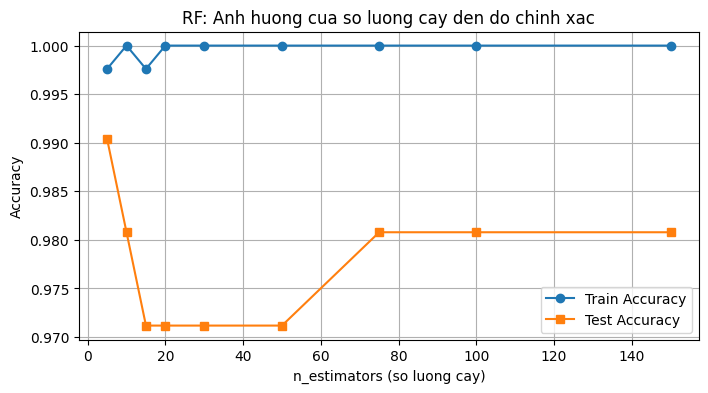

In [47]:
num_trees = [5, 10, 15, 20, 30, 50, 75, 100, 150]
train_acc = []
test_acc = []

####
# Yêu cầu 12: Code
# Vẽ biểu đồ biểu thị mối quan hệ giữa số lượng cây và độ chính xác
# Nhận xét kết quả

for n_tree in num_trees:
    rf_model = RandomForestClassifier(n_estimators=n_tree, random_state=random_state)
    rf_model.fit(X_train, y_train)

    y_train_pred = rf_model.predict(X_train)
    y_test_pred = rf_model.predict(X_test)

    train_acc.append(accuracy_score(y_train, y_train_pred))
    test_acc.append(accuracy_score(y_test, y_test_pred))

plt.figure(figsize=(8, 4))
plt.plot(num_trees, train_acc, marker='o', label='Train Accuracy')
plt.plot(num_trees, test_acc, marker='s', label='Test Accuracy')
plt.xlabel('n_estimators (so luong cay)')
plt.ylabel('Accuracy')
plt.title('RF: Anh huong cua so luong cay den do chinh xac')
plt.legend()
plt.grid(True)
plt.show()

# Nhan xet mau:
## - Khi n_estimators tang, hieu suat test thuong on dinh hon.
## - Sau mot nguong nhat dinh, do chinh xac tang rat it nhung chi phi tinh toan tang.
####

##### Sử dụng GridSearchCV để khảo sát

In [54]:
dict_param = {
    'max_depth': [3, 11, 15, 24, 27],
    'min_samples_leaf': [1, 5, 7, 9, 15, 24],
    'max_features':  [4, 6, 10, 16],
    'n_estimators': [20, 30, 40]
}
best_forest = grid_search('random-forest', X_train, y_train, n_jobs=-1, dict_param=dict_param)

Best modelRandomForestClassifier(max_depth=15, max_features=4, n_estimators=30)
Best parameters: {'max_depth': 15, 'max_features': 4, 'min_samples_leaf': 1, 'n_estimators': 30}


In [49]:
# Yêu cầu 13:
''' - Giải thích ý nghĩa của các biến: max_depth, min_samples_leaf, max_features, n_estimators trong mô hình RF
    - Grid_seach được sử dụng nhằm mục đích gì?
    - Kết quả thu được là gì?
'''

# Y nghia sieu tham so trong RF:
## - max_depth: do sau toi da cua moi cay; qua lon de overfit.
## - min_samples_leaf: so mau toi thieu o node la; tang gia tri nay giup giam overfit.
## - max_features: so luong feature duoc xem xet khi tach node; tao su da dang giua cac cay.
## - n_estimators: so cay trong rung; tang so cay thuong giup du doan on dinh hon.

# Vai tro GridSearchCV:
## - Thu he thong tat ca to hop tham so trong dict_param.
## - Danh gia bang cv=5 va chon cau hinh co F1 tot nhat.

# Ket qua thu duoc:
## - best_forest la mo hinh Random Forest tot nhat theo tieu chi F1 cross-validation.
## - Mo hinh nay se duoc dung de danh gia o Yeu cau 14 va phan tich feature importance o Yeu cau 15.

' - Giải thích ý nghĩa của các biến: max_depth, min_samples_leaf, max_features, n_estimators trong mô hình RF\n    - Grid_seach được sử dụng nhằm mục đích gì?\n    - Kết quả thu được là gì?\n'

##### Đánh giá Mô hình RF tốt nhất

In [50]:
# Yêu cầu 14: Gợi ý: Sử dụng hàm evaluate()
####
# Code
if 'best_forest' not in globals():
    best_forest = grid_search('random-forest', X_train, y_train, n_jobs=-1, dict_param=dict_param)

best_forest.fit(X_train, y_train)
best_forest_train_f1, best_forest_test_f1 = evaluate(X_train, y_train, X_test, y_test, best_forest)

print('\nTóm tắt kết quả best RF:')
print(f'- Train F1: {best_forest_train_f1:.4f}')
print(f'- Test F1 : {best_forest_test_f1:.4f}')
####

Best modelRandomForestClassifier(max_depth=15, max_features=4, n_estimators=20)
Best parameters: {'max_depth': 15, 'max_features': 4, 'min_samples_leaf': 1, 'n_estimators': 20}
Train Accuracy: 1.0
Train Precision:  1.0
Train Recall:  1.0
Train F1-score: 1.0
Train Confusion Matrix:
[[160   0]
 [  0 256]]
--------------------------------------------------
Test Accuracy: 0.9807692307692307
Test Precision: 0.984375
Test Recall:  0.984375
Test F1-score: 0.984375
Test Confusion Matrix:
[[39  1]
 [ 1 63]]

Tóm tắt kết quả best RF:
- Train F1: 1.0000
- Test F1 : 0.9844


##### Nhận xét về độ quan trọng của từng feature trong tập dữ liệu sử dụng thuộc tính feature_importances_

Feature importances (RF)
Feature  0 - 0.21457541452977696
Feature  1 - 0.18275086140922642
Feature  2 - 0.11280354385650113
Feature  3 - 0.1053979242787108
Feature  4 - 0.05240002714380214
Feature  5 - 0.042203246395943486
Feature  6 - 0.03930031120887787
Feature  7 - 0.035265450508296915
Feature  8 - 0.03524965136278147
Feature  9 - 0.03486629389779915
Feature  10 - 0.02980050427020516
Feature  11 - 0.02641267007404071
Feature  12 - 0.02596730639229903
Feature  13 - 0.02531857224138201
Feature  14 - 0.02170029907842095
Feature  15 - 0.015987923351935895


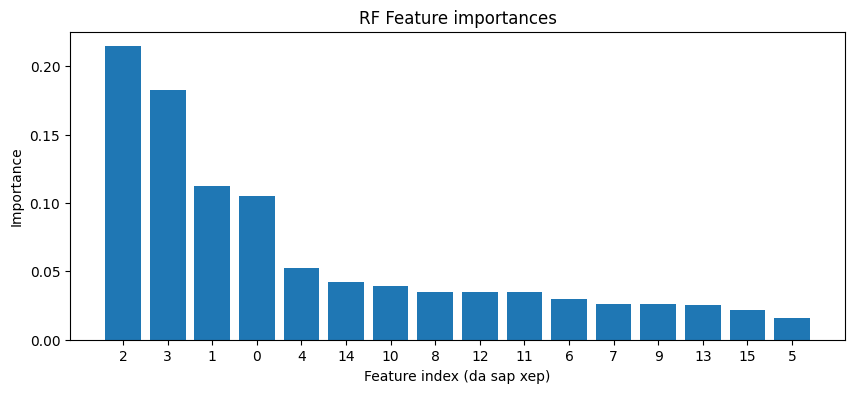

In [51]:
# Yêu cầu 15:
####
# Code
# Vẽ biểu đồ hiển thị các feature giảm dần theo độ quan trọng
# Nhận xét kết quả

if 'best_forest' not in globals():
    best_forest = grid_search('random-forest', X_train, y_train, n_jobs=-1, dict_param=dict_param)
best_forest.fit(X_train, y_train)

importances_rf = best_forest.feature_importances_
indices_rf = np.argsort(importances_rf)[::-1]

print('Feature importances (RF)')
for i in range(len(indices_rf)):
    print('Feature ', i, '-', importances_rf[indices_rf[i]])

plt.figure(figsize=(10, 4))
plt.title('RF Feature importances')
plt.bar(range(len(indices_rf)), importances_rf[indices_rf])
plt.xticks(range(len(indices_rf)), indices_rf)
plt.xlabel('Feature index (da sap xep)')
plt.ylabel('Importance')
plt.show()

# Nhan xet mau:
## - Feature co importance cao dong gop manh hon vao quyet dinh cua mo hinh.
## - Co the can nhac loai bo cac feature importance rat thap o buoc tiep theo.
####

##### Thử nghiệm bổ sung: Thử bỏ đi một số thuộc tính có độ quan trọng thấp và quan sát sự thay đổi của hiệu suất mô hình

Train Accuracy: 1.0
Train Precision:  1.0
Train Recall:  1.0
Train F1-score: 1.0
Train Confusion Matrix:
[[160   0]
 [  0 256]]
--------------------------------------------------
Test Accuracy: 0.9807692307692307
Test Precision: 0.984375
Test Recall:  0.984375
Test F1-score: 0.984375
Test Confusion Matrix:
[[39  1]
 [ 1 63]]
Train Accuracy: 1.0
Train Precision:  1.0
Train Recall:  1.0
Train F1-score: 1.0
Train Confusion Matrix:
[[160   0]
 [  0 256]]
--------------------------------------------------
Test Accuracy: 1.0
Test Precision: 1.0
Test Recall:  1.0
Test F1-score: 1.0
Test Confusion Matrix:
[[40  0]
 [ 0 64]]
Train Accuracy: 1.0
Train Precision:  1.0
Train Recall:  1.0
Train F1-score: 1.0
Train Confusion Matrix:
[[160   0]
 [  0 256]]
--------------------------------------------------
Test Accuracy: 0.9807692307692307
Test Precision: 0.984375
Test Recall:  0.984375
Test F1-score: 0.984375
Test Confusion Matrix:
[[39  1]
 [ 1 63]]
Train Accuracy: 0.9975961538461539
Train Precisio

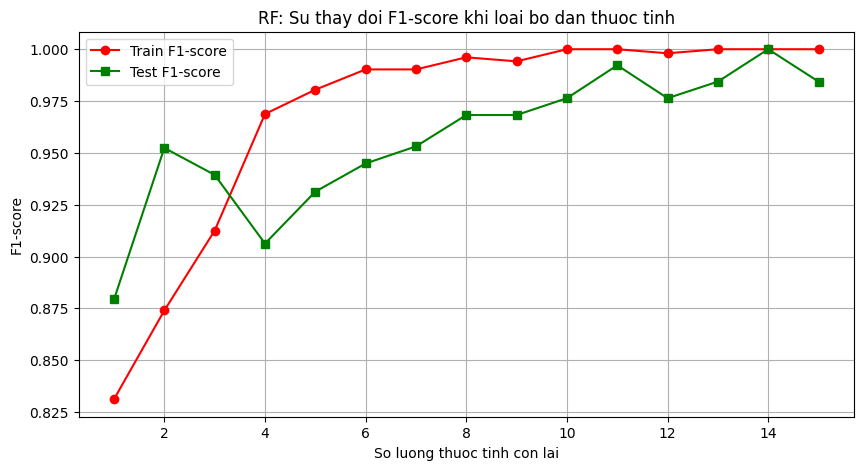

In [52]:
# Yêu cầu 16:
####
# Code
# Vẽ biểu đồ biểu thị sự thay đổi của f1-score khi loại bỏ dần các thuộc tính trên cả tập train và test
# Nhận xét kết quả

if 'best_forest' not in globals():
    best_forest = grid_search('random-forest', X_train, y_train, n_jobs=-1, dict_param=dict_param)
best_forest.fit(X_train, y_train)

importances_rf = best_forest.feature_importances_
indices_rf = np.argsort(importances_rf)[::-1]

train_scores_rf = []
test_scores_rf = []
num_features_rf = []

for i in range(1, len(indices_rf)):
    selected_indices_rf = indices_rf[:-i]

    X_train_reduced_rf = X_train[:, selected_indices_rf]
    X_test_reduced_rf = X_test[:, selected_indices_rf]

    best_forest.fit(X_train_reduced_rf, y_train)
    train_f1_rf, test_f1_rf = evaluate(X_train_reduced_rf, y_train, X_test_reduced_rf, y_test, best_forest)

    train_scores_rf.append(train_f1_rf)
    test_scores_rf.append(test_f1_rf)
    num_features_rf.append(len(selected_indices_rf))

plt.figure(figsize=(10, 5))
plt.plot(num_features_rf, train_scores_rf, label='Train F1-score', marker='o', color='r')
plt.plot(num_features_rf, test_scores_rf, label='Test F1-score', marker='s', color='g')
plt.xlabel('So luong thuoc tinh con lai')
plt.ylabel('F1-score')
plt.title('RF: Su thay doi F1-score khi loai bo dan thuoc tinh')
plt.legend()
plt.grid(True)
plt.show()

# Nhan xet mau:
## - Loai bo mot so feature yeu co the giup mo hinh gon hon va co luc cai thien F1 test.
## - Loai bo qua nhieu thuoc tinh se lam giam F1 do mat thong tin quan trong.
####

### 2. Bài toán: Dự điểm số của học sinh sử dụng Decsion Tree và Random Forest (40%)
Mục tiêu:
- Xây dựng mô hình Decision Tree Regression và Random Forest Regression sử dụng thư viện sklearn.
- Khảo sát và tối ưu mô hình bằng việc tìm kiếm các siêu tham số và lựa chọn đặc trưng.
- Áp dụng hai mô hình để giải quyết bài toán thực tế (Dự đoán điểm số).
- Đánh giá chất lượng mô hình bằng độ đo thích hợp.

Dữ liệu:
- Thể hiện dưới dạng bảng, trong đó mỗi hàng tương ứng với một học sinh, mỗi cột thể hiện thông tin cá nhân, học tập, và môi trường sống của học sinh.
- Các trường thuộc tính tồn tại ở nhiều dạng khác nhau: category, binary, numeric.
- Thuộc tính nhãn lớp 'G3' là một thuộc tính có kiểu dữ liệu numeric.

Mô hình hóa bài toán: Bài toán hồi quy (Regression Task)
- Đầu vào: N vector D chiều (ma trận cỡ N x D), tương ứng N cá thể với D thuộc tính.
- Đầu ra: Điểm số cụ thể của học sinh.

Nhiệm vụ:
- Tìm hiểu và tải dữ liệu về từ trang: https://archive.ics.uci.edu/dataset/320/student+performance.
- Giải nén folder 'student.zip'. Sau đó, hợp nhất dữ liệu ở 2 file csv có tên 'student-mat.csv' và 'student-por.csv' thành 1 file đặt tên là 'student.csv'.
- 'student.csv' chính là dataset cuối cùng dùng cho Bài toán 2.
- Tiếp tục thực hiện các bước tương tự như Bài toán 1.
- Viết báo cáo trình bày, giải thích chi tiết các bước và nhận xét kết quả thu được.